# El Perceptrón Simple desde Cero

**Materiales desarrollados por Matías Barreto, 2026**

**Tecnicatura Superior en Ciencias de Datos e IA**
* **Nomenclatura Oficial:** Procesamiento de Lenguaje Natural
* **Nombre de Trabajo:** Laboratorio de PLN: Analítica, Textos y Cultura

---

## Objetivo
Comprender las bases fundamentales de las redes neuronales artificiales mediante el diseño, programación y entrenamiento del Perceptrón Simple desde cero en Python puro.

## Resultados de aprendizaje
Al final de este notebook vas a poder:
1. Describir matemáticamente el funcionamiento de una neurona artificial elemental.
2. Programar la regla de aprendizaje del Perceptrón (ajuste de pesos y sesgo) sin librerías de deep learning.
3. Analizar las limitaciones lógicas del Perceptrón Simple para problemas linealmente no separables (como XOR).



## Terminología clave (Microglosario)

* **✦ Neurona Artificial (Perceptrón):** Unidad de procesamiento elemental que suma entradas multiplicadas por pesos (weights), añade un sesgo (bias) y aplica una función de activación para dar un resultado binario.
* **✦ Pesos y Sesgo (Weights & Bias):** Parámetros ajustables de una red neuronal; los pesos determinan la fuerza de la señal y el sesgo desplaza la frontera de decisión.
* **✦ Función de Activación:** Función matemática que determina si una neurona debe activarse (disparar información) basándose en la suma neta ponderada de sus entradas.



## 1. Importación de Librerías
Solo usaremos NumPy para el álgebra lineal básica y Matplotlib para graficar.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Fijamos la semilla para que los números aleatorios sean siempre los mismos
np.random.seed(42)

print("OK: Librerías listas y semilla configurada.")


OK: Librerías listas y semilla configurada.


---
## 2. El Dataset Didáctico
Trabajaremos con 6 frases muy claras en español rioplatense para poder rastrear manualmente cada actualización de la neurona.


In [2]:
frases = [
    "Amo el verano en Buenos Aires",
    "No me gusta el tráfico matutino",
    "Este asado está espectacular",
    "Qué bajón, perdí el colectivo",
    "Me encanta salir los domingos",
    "Detesto el calor húmedo"
]

# Etiquetas: 1 = Sentimiento Positivo, 0 = Sentimiento Negativo
etiquetas = np.array([1, 0, 1, 0, 1, 0])

for i, frase in enumerate(frases):
    sentido = "POSITIVO" if etiquetas[i] == 1 else "NEGATIVO"
    print(f"Frase {i+1}: [{sentido}] '{frase}'")


Frase 1: [POSITIVO] 'Amo el verano en Buenos Aires'
Frase 2: [NEGATIVO] 'No me gusta el tráfico matutino'
Frase 3: [POSITIVO] 'Este asado está espectacular'
Frase 4: [NEGATIVO] 'Qué bajón, perdí el colectivo'
Frase 5: [POSITIVO] 'Me encanta salir los domingos'
Frase 6: [NEGATIVO] 'Detesto el calor húmedo'


---
## 3. Vocabulario y Vectorización Manual
Definimos un vocabulario clave y construimos un vectorizador binario manual (Bag of Words binario) para entender exactamente de dónde salen los números.


In [3]:
# Vocabulario con palabras cargadas emocionalmente
vocabulario = [
    "amo", "no", "gusta", "asado", "espectacular", 
    "bajón", "perdí", "encanta", "detesto", "calor"
]

def vectorizar_frase(frase, vocabulario):
    # Separamos la frase en palabras en minúscula
    palabras = frase.lower().split()
    
    vector = []
    for palabra in vocabulario:
        if palabra in palabras:
            vector.append(1)
        else:
            vector.append(0)
    return np.array(vector)

# Convertimos todas las frases del corpus
vectores_frases = []
for f in frases:
    v = vectorizar_frase(f, vocabulario)
    vectores_frases.append(v)

X = np.array(vectores_frases)
y = etiquetas

print("Frase 1 original:  ", frases[0])
print("Frase 1 vectorizada:", X[0])
print("Vocabulario:        ", vocabulario)


Frase 1 original:   Amo el verano en Buenos Aires
Frase 1 vectorizada: [1 0 0 0 0 0 0 0 0 0]
Vocabulario:         ['amo', 'no', 'gusta', 'asado', 'espectacular', 'bajón', 'perdí', 'encanta', 'detesto', 'calor']


---
## 4. Inicialización de los Parámetros
Inicializamos los pesos de forma aleatoria y el bias en cero.


In [4]:
n_caracteristicas = len(vocabulario)

# Pesos aleatorios usando una distribución normal
pesos = np.random.randn(n_caracteristicas)

# Bias inicializado en cero
bias = 0.0

print("Pesos iniciales de las palabras:")
for i, palabra in enumerate(vocabulario):
    print(f"  {palabra:15s} -> peso inicial: {pesos[i]:.4f}")
print(f"\nBias inicial: {bias}")


Pesos iniciales de las palabras:
  amo             -> peso inicial: 0.4967
  no              -> peso inicial: -0.1383
  gusta           -> peso inicial: 0.6477
  asado           -> peso inicial: 1.5230
  espectacular    -> peso inicial: -0.2342
  bajón           -> peso inicial: -0.2341
  perdí           -> peso inicial: 1.5792
  encanta         -> peso inicial: 0.7674
  detesto         -> peso inicial: -0.4695
  calor           -> peso inicial: 0.5426

Bias inicial: 0.0


---
## 5. Función de Activación: Escalón
La función escalón es el interruptor de nuestra neurona. Si el número de entrada es mayor a 0, devuelve 1 (activo). En caso contrario, devuelve 0.


In [5]:
def activacion_escalon(z):
    if z > 0:
        return 1
    else:
        return 0

# Probamos con valores de ejemplo
print("Entrada 2.5  -> Salida:", activacion_escalon(2.5))
print("Entrada -1.2 -> Salida:", activacion_escalon(-1.2))


Entrada 2.5  -> Salida: 1
Entrada -1.2 -> Salida: 0


---
## 6. Función de Predicción (Forward Pass)
Para predecir, multiplicamos los vectores de entrada por los pesos de la neurona, sumamos el bias, y pasamos el resultado por la función escalón.


In [6]:
def predecir(x, pesos, bias):
    # Suma ponderada: z = w1*x1 + w2*x2 + ... + b
    suma_ponderada = np.dot(pesos, x) + bias
    
    # Pasamos por la función escalón
    prediccion = activacion_escalon(suma_ponderada)
    return prediccion

# Probamos predecir la primera frase antes de entrenar
pred_inicial = predecir(X[0], pesos, bias)
print(f"Frase: '{frases[0]}'")
print(f"Predicción inicial (aleatoria): {pred_inicial} | Real: {y[0]}")


Frase: 'Amo el verano en Buenos Aires'
Predicción inicial (aleatoria): 1 | Real: 1


---
## 7. El Algoritmo de Entrenamiento (La Regla del Perceptrón)

### Regla de actualización:
Cuando el modelo comete un error, ajusta sus parámetros usando esta simple fórmula:
$$w_i = w_i + \alpha \cdot error \cdot x_i$$
$$b = b + \alpha \cdot error$$
Donde el $error = y_{real} - y_{predicho}$.


In [7]:
tasa_aprendizaje = 0.2
epocas = 15
historial_errores = []

print("Iniciando entrenamiento...")
print("=" * 50)

for epoca in range(epocas):
    errores_esta_epoca = 0
    
    for i in range(len(X)):
        x_i = X[i]
        y_real = y[i]
        
        # 1. Hacemos la predicción
        y_pred = predecir(x_i, pesos, bias)
        
        # 2. Calculamos el error
        error = y_real - y_pred
        
        # 3. Si hay error, actualizamos pesos y bias
        if error != 0:
            pesos += tasa_aprendizaje * error * x_i
            bias += tasa_aprendizaje * error
            errores_esta_epoca += 1
            
    historial_errores.append(errores_esta_epoca)
    print(f"Época {epoca+1:2d} -> Errores cometidos: {errores_esta_epoca}")

print("=" * 50)
print("Entrenamiento finalizado. Pesos y Bias ajustados!")


Iniciando entrenamiento...
Época  1 -> Errores cometidos: 2
Época  2 -> Errores cometidos: 1
Época  3 -> Errores cometidos: 2
Época  4 -> Errores cometidos: 2
Época  5 -> Errores cometidos: 1
Época  6 -> Errores cometidos: 1
Época  7 -> Errores cometidos: 0
Época  8 -> Errores cometidos: 0
Época  9 -> Errores cometidos: 0
Época 10 -> Errores cometidos: 0
Época 11 -> Errores cometidos: 0
Época 12 -> Errores cometidos: 0
Época 13 -> Errores cometidos: 0
Época 14 -> Errores cometidos: 0
Época 15 -> Errores cometidos: 0
Entrenamiento finalizado. Pesos y Bias ajustados!


### Curva de Aprendizaje
Graficamos la cantidad de errores cometidos por época para ver cómo aprende la neurona a lo largo del tiempo.


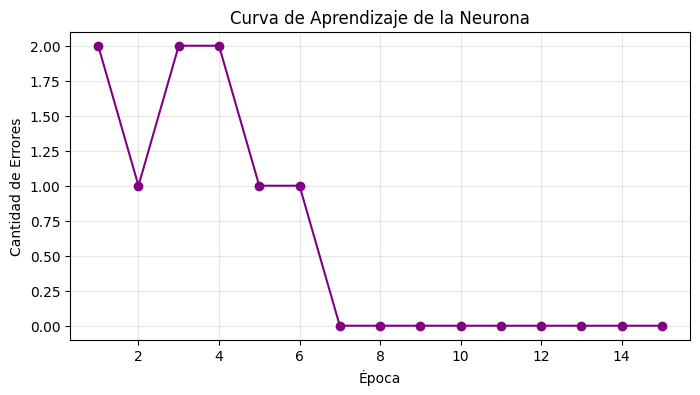

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, epocas + 1), historial_errores, marker='o', color='purple')
plt.xlabel("Época")
plt.ylabel("Cantidad de Errores")
plt.title("Curva de Aprendizaje de la Neurona")
plt.grid(True, alpha=0.3)
plt.show()


---
## 8. ¿Qué Aprendió la Neurona? (Análisis de Pesos)
Miremos qué importancia le dio la neurona a cada una de nuestras palabras después del entrenamiento.


In [9]:
print("Importancia aprendida para cada palabra:")
print("=" * 50)

# Ordenamos las palabras por su peso final (de mayor a menor)
indices_ordenados = np.argsort(pesos)[::-1]

for idx in indices_ordenados:
    palabra = vocabulario[idx]
    peso_final = pesos[idx]
    
    if peso_final > 0:
        rol = "POSITIVO" 
    elif peso_final < 0:
        rol = "NEGATIVO"
    else:
        rol = "NEUTRO"
        
    print(f"  {palabra:15s} -> Peso final: {peso_final:6.2f} | Rol: {rol}")

print(f"\nBias final (umbral): {bias:.2f}")


Importancia aprendida para cada palabra:
  asado           -> Peso final:   1.52 | Rol: POSITIVO
  encanta         -> Peso final:   0.97 | Rol: POSITIVO
  amo             -> Peso final:   0.90 | Rol: POSITIVO
  perdí           -> Peso final:   0.58 | Rol: POSITIVO
  calor           -> Peso final:   0.54 | Rol: POSITIVO
  gusta           -> Peso final:   0.45 | Rol: POSITIVO
  bajón           -> Peso final:  -0.23 | Rol: NEGATIVO
  espectacular    -> Peso final:  -0.23 | Rol: NEGATIVO
  no              -> Peso final:  -0.34 | Rol: NEGATIVO
  detesto         -> Peso final:  -0.47 | Rol: NEGATIVO

Bias final (umbral): -0.60


## Consigna de Lectura e Interpretación
**Pregunta para pensar:** Mira los pesos finales de las palabras *'amo'*, *'no'* y *'bajón'*. ¿Coinciden con la emoción humana que transmiten en el mundo real? ¿Qué palabra tiene un peso de cero y por qué crees que la neurona decidió ignorarla? (Pista: analiza en qué frases del dataset aparece).
